**[Text 01]**

# Video-to-3D: Reconstructing Dynamic Scenes from Synthetic Video

This notebook builds a toy video-to-3D pipeline entirely from scratch. We generate a synthetic "video" of 3D objects moving and rotating, then reconstruct the dynamic 3D scene by estimating per-point motion (scene flow) between frames. This connects optical flow (2D motion in images) → scene flow (3D motion in world) → dynamic 3D reconstruction.

**Why this matters:**
- **Static 3D models** capture a single timestep. Real scenes move.
- **Optical flow** tells us how pixels moved in 2D. With depth, we lift this to **scene flow** — 3D motion.
- **4D Gaussian Splatting** (W16 main tutorial) avoids accumulating flow errors by jointly optimizing all timesteps. This notebook shows WHY that's necessary.

**Connections:**
- [W14: 3DGS Basics](https://artifocial.com/blog/gaussian-splatting-explained-2026-apr-03) — static scene reconstruction
- [W16 Trend Tutorial: The 4D Gaussian Frontier](https://artifocial.com/blog/4d-gaussian-frontier-2026-apr-17) — why scenes are 4D
- [W16: 4DGS Explained](https://artifocial.com/blog/4d-gaussian-splatting-explained-2026-apr-17) — the learned motion field
- [W15: Post-Transformer Architectures (SSMs)](https://artifocial.com/blog/post-transformer-architectures-2026-apr-09) — temporal modeling beyond transformers

**References:**
- RAFT: [Recurrent All-Pairs Field Transforms for Optical Flow](https://arxiv.org/abs/2003.12039)
- Neural Scene Flow Fields: [Li et al., 2021](https://arxiv.org/abs/2011.13084)
- 3DGS: [Kerbl et al., 2023](https://arxiv.org/abs/2308.04079)
- 4DGS: [Wu et al., 2023](https://arxiv.org/abs/2310.08528)


## ⚠️ What this toy hands to the model (read this first)

Before we start, a clear disclosure. In a real video-to-3D pipeline, the two hardest problems are **estimating optical flow** and **estimating per-pixel depth**. Both are active research areas and both fail in characteristic ways on real footage.

**This notebook gives both of them to the model as ground truth.** Specifically:

- **Optical flow is analytical.** We compute pixel motion by projecting the known 3D scene points at consecutive timesteps and subtracting — not by running a real flow estimator (RAFT, FlowNet) on pixel intensities.
- **Depth is analytical.** We have exact per-point $Z$ from the synthetic scene parameters — not from stereo, not from a learned monocular estimator (MiDaS, Depth Anything), not from structure-from-motion.

Every number you will see in this notebook — including the headline "flow-aware beats static by 29×" ratio — is measured with those two inputs treated as correct. The ratio is **real**, but it **flatters** the flow-aware pipeline: the only error source is the missing $\Delta Z$ in the lift step; flow itself is exact, and so is depth.

Why build it this way? Because the didactic target is the **lifting and propagation machinery** (how 2D motion becomes 3D motion, how errors compound frame-by-frame, why global optimization beats local chasing). Isolating that machinery from flow-estimation and depth-estimation errors is what makes the drift story legible.

A planned v2 follow-up retires both cheats — pyramidal Lucas–Kanade on rendered image intensities for flow, and depth-from-flow via epipolar geometry for depth — and reports what the honest multiple actually is. Watch that one for what survives contact with real inputs; this one for why the pipeline shape is the way it is.

In [1]:
# [Code 01]
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.patches import FancyArrowPatch
from mpl_toolkits.mplot3d.proj3d import proj_transform

# Seed for reproducibility
np.random.seed(42)

# Plotting defaults
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11

print("Setup complete. NumPy + Matplotlib ready.")
print(f"NumPy version: {np.__version__}")

Setup complete. NumPy + Matplotlib ready.
NumPy version: 2.2.6


**[Text 02]**

## The Synthetic Scene

We create a simple dynamic 3D scene with **known ground truth**:
- A **sphere** that translates rightward over 20 frames
- A **cube** that rotates around the y-axis over 20 frames
- A **fixed background point** (no motion)

We observe this scene from a fixed camera using a pinhole projection model. Each frame gives us a 2D image of the 3D scene. Our task: given the 2D images, reconstruct the 3D motion.


In [2]:
# [Code 02]
def generate_sphere_points(center, radius=1.0, n_points=200):
    """
    Generate points on the surface of a sphere using Fibonacci sphere.
    center: (3,) array
    Returns: (n_points, 3) array of 3D points on sphere surface
    """
    indices = np.arange(0, n_points, dtype=float) + 0.5
    phi = np.arccos(1 - 2*indices/n_points)
    theta = np.pi * (1 + 5**0.5) * indices
    
    x = radius * np.cos(theta) * np.sin(phi)
    y = radius * np.sin(theta) * np.sin(phi)
    z = radius * np.cos(phi)
    
    points = np.stack([x, y, z], axis=1)
    return points + center[np.newaxis, :]

def generate_cube_points(center, size=1.0, n_points_per_face=50):
    """
    Generate points on the surface of a cube.
    center: (3,) array
    Returns: (n_points, 3) array of 3D points on cube surface
    """
    half_size = size / 2.0
    points = []
    
    # Generate points on each face
    n_edge = int(np.sqrt(n_points_per_face))
    u = np.linspace(-half_size, half_size, n_edge)
    v = np.linspace(-half_size, half_size, n_edge)
    uu, vv = np.meshgrid(u, v)
    
    # 6 faces: ±x, ±y, ±z
    points.append(np.stack([np.full_like(uu, half_size), uu, vv], axis=-1))  # +x face
    points.append(np.stack([np.full_like(uu, -half_size), uu, vv], axis=-1))  # -x face
    points.append(np.stack([uu, np.full_like(uu, half_size), vv], axis=-1))   # +y face
    points.append(np.stack([uu, np.full_like(uu, -half_size), vv], axis=-1))  # -y face
    points.append(np.stack([uu, vv, np.full_like(uu, half_size)], axis=-1))   # +z face
    points.append(np.stack([uu, vv, np.full_like(uu, -half_size)], axis=-1))  # -z face
    
    all_points = np.concatenate([p.reshape(-1, 3) for p in points], axis=0)
    return all_points + center[np.newaxis, :]

def generate_scene(t, n_frames=20):
    """
    Generate a dynamic 3D scene at time t.
    t: timestep (0 to n_frames-1)
    Returns: (N, 3) array of 3D points, list of object labels for visualization
    """
    # Normalize t to [0, 1]
    t_norm = t / (n_frames - 1) if n_frames > 1 else 0
    
    points = []
    labels = []
    
    # Sphere: translates rightward
    sphere_center = np.array([2.0 * t_norm, 0.0, 5.0])  # moves from x=0 to x=2
    sphere_pts = generate_sphere_points(sphere_center, radius=0.3, n_points=150)
    points.append(sphere_pts)
    labels.extend(['sphere'] * len(sphere_pts))
    
    # Cube: rotates around y-axis
    angle = 2 * np.pi * t_norm  # full rotation over sequence
    cube_center = np.array([-1.0, 0.0, 5.0])
    cube_pts = generate_cube_points(cube_center, size=0.5, n_points_per_face=40)
    
    # Rotate around y-axis (center at cube_center)
    cos_a, sin_a = np.cos(angle), np.sin(angle)
    rot_matrix = np.array([
        [cos_a, 0, sin_a],
        [0, 1, 0],
        [-sin_a, 0, cos_a]
    ])
    cube_pts_centered = cube_pts - cube_center[np.newaxis, :]
    cube_pts_rotated = cube_pts_centered @ rot_matrix.T + cube_center[np.newaxis, :]
    
    points.append(cube_pts_rotated)
    labels.extend(['cube'] * len(cube_pts_rotated))
    
    # Background point (fixed, far away)
    bg_pt = np.array([[0.0, 0.0, 15.0]])
    points.append(bg_pt)
    labels.extend(['background'])
    
    all_points = np.concatenate(points, axis=0)
    labels = np.array(labels)
    
    return all_points, labels

# Test: generate scenes at a few timesteps
scene_0, labels_0 = generate_scene(0, n_frames=20)
scene_19, labels_19 = generate_scene(19, n_frames=20)

print(f"Scene at t=0: {scene_0.shape[0]} points")
print(f"Scene at t=19: {scene_19.shape[0]} points")
print(f"Sphere at t=0, x-position: {scene_0[labels_0 == 'sphere', 0].mean():.3f}")
print(f"Sphere at t=19, x-position: {scene_19[labels_19 == 'sphere', 0].mean():.3f}")

Scene at t=0: 367 points
Scene at t=19: 367 points
Sphere at t=0, x-position: 0.000
Sphere at t=19, x-position: 2.000


In [3]:
# [Code 03]
def build_intrinsic_matrix(focal_length=500.0, cx=320.0, cy=240.0):
    """
    Build 3x3 camera intrinsic matrix K for pinhole camera.
    """
    K = np.array([
        [focal_length, 0, cx],
        [0, focal_length, cy],
        [0, 0, 1]
    ])
    return K

def project_3d_to_2d(points_3d, K):
    """
    Project 3D points to 2D image plane using pinhole camera model.
    points_3d: (N, 3) array of 3D points in camera frame
    K: (3, 3) intrinsic matrix
    Returns: (N, 2) array of 2D pixel coordinates, (N,) array of depths Z
    """
    # Homogeneous projection: p_homo = K @ p_3d
    p_homo = (K @ points_3d.T).T  # (N, 3)
    
    # Normalize by depth (Z coordinate)
    depths = p_homo[:, 2]
    p_2d = p_homo[:, :2] / (depths[:, np.newaxis] + 1e-8)
    
    return p_2d, depths

# Build camera
K = build_intrinsic_matrix(focal_length=500.0, cx=320.0, cy=240.0)

# Project scenes
proj_0, depth_0 = project_3d_to_2d(scene_0, K)
proj_19, depth_19 = project_3d_to_2d(scene_19, K)

print(f"Intrinsic matrix K:")
print(K)
print(f"\nProjected scene at t=0: {proj_0.shape}")
print(f"Depth range at t=0: {depth_0.min():.2f} to {depth_0.max():.2f}")

Intrinsic matrix K:
[[500.   0. 320.]
 [  0. 500. 240.]
 [  0.   0.   1.]]

Projected scene at t=0: (367, 2)
Depth range at t=0: 4.70 to 15.00


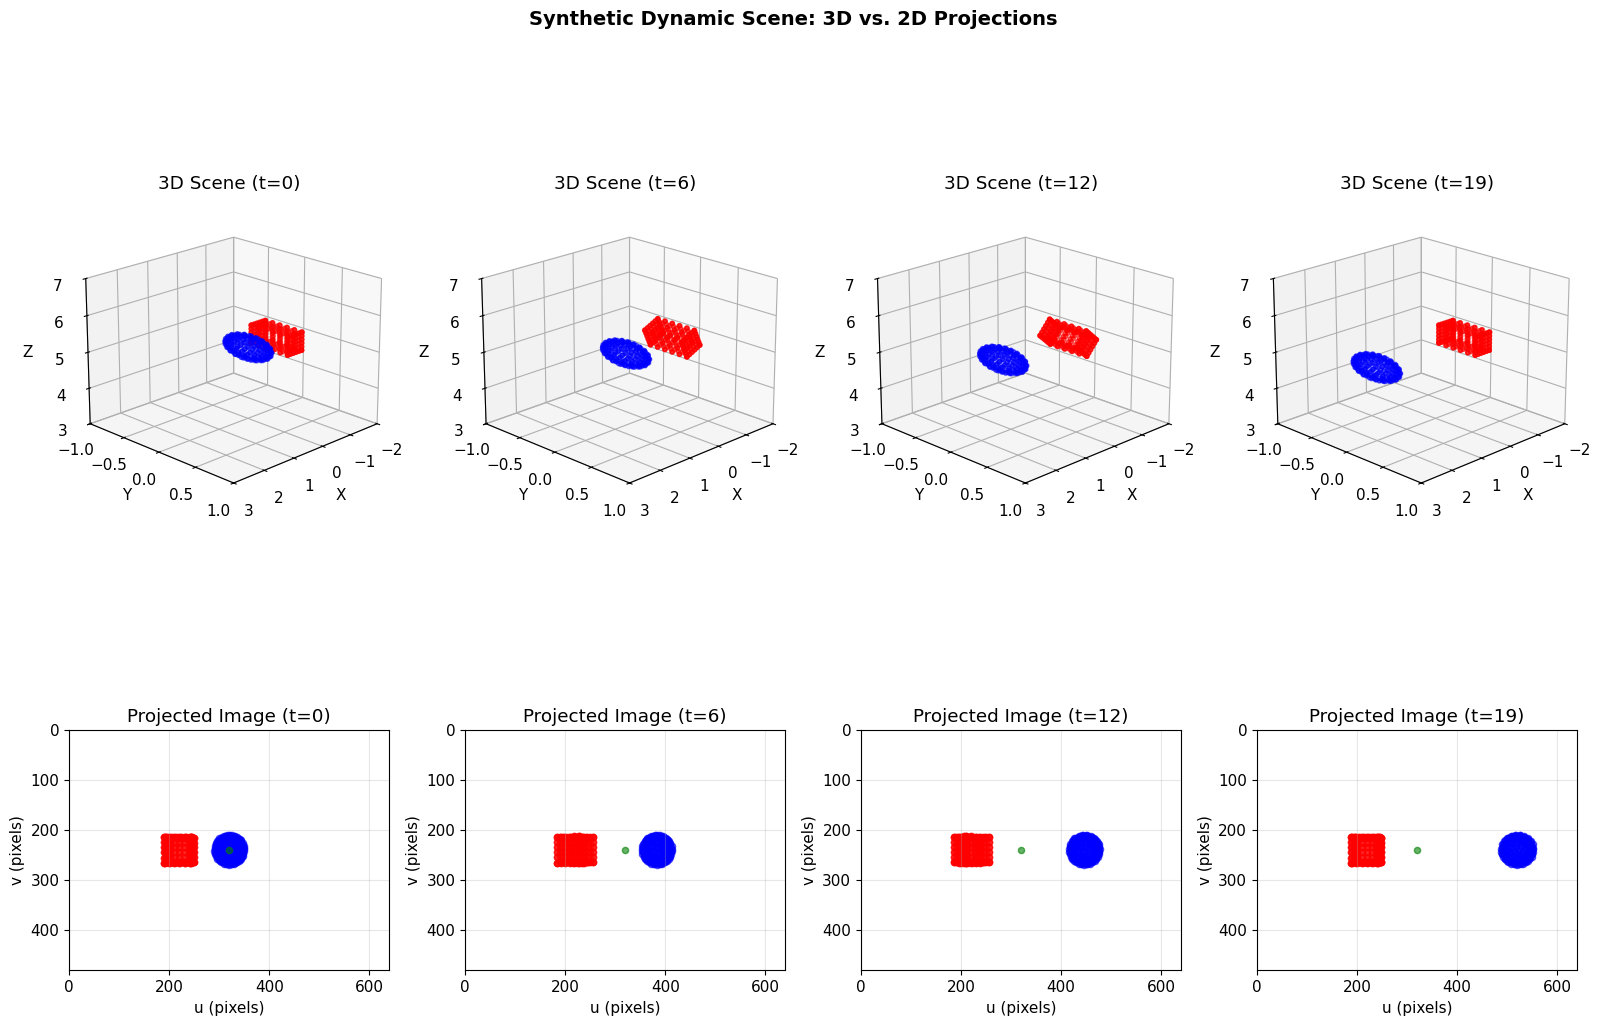

Visualized 4 timesteps: t=0, 6, 12, 19


In [4]:
# [Result 01]
fig = plt.figure(figsize=(16, 12))

# Timestamps to visualize
timestamps = [0, 6, 12, 19]

for idx, t in enumerate(timestamps):
    scene_t, labels_t = generate_scene(t, n_frames=20)
    proj_t, depth_t = project_3d_to_2d(scene_t, K)
    
    # 3D view
    ax_3d = fig.add_subplot(2, 4, idx + 1, projection='3d')
    
    # Color by object type
    colors = np.array([{'sphere': 'blue', 'cube': 'red', 'background': 'green'}.get(l, 'gray') for l in labels_t])
    for color in ['blue', 'red', 'green']:
        mask = colors == color
        ax_3d.scatter(scene_t[mask, 0], scene_t[mask, 1], scene_t[mask, 2], 
                     c=color, s=10, alpha=0.6, label=color.capitalize())
    
    ax_3d.set_xlabel('X')
    ax_3d.set_ylabel('Y')
    ax_3d.set_zlabel('Z')
    ax_3d.set_xlim(-2, 3)
    ax_3d.set_ylim(-1, 1)
    ax_3d.set_zlim(3, 7)
    ax_3d.set_title(f'3D Scene (t={t})')
    ax_3d.view_init(elev=20, azim=45)
    
    # 2D projected view
    ax_2d = fig.add_subplot(2, 4, idx + 5)
    
    for color in ['blue', 'red', 'green']:
        mask = colors == color
        ax_2d.scatter(proj_t[mask, 0], proj_t[mask, 1], c=color, s=20, alpha=0.6, label=color.capitalize())
    
    ax_2d.set_xlabel('u (pixels)')
    ax_2d.set_ylabel('v (pixels)')
    ax_2d.set_xlim(0, 640)
    ax_2d.set_ylim(480, 0)  # flip y for image coordinates
    ax_2d.set_title(f'Projected Image (t={t})')
    ax_2d.grid(True, alpha=0.3)
    ax_2d.set_aspect('equal')

plt.suptitle('Synthetic Dynamic Scene: 3D vs. 2D Projections', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Visualized 4 timesteps: t=0, 6, 12, 19")

**[Text 03]**

## Optical Flow: Motion in the Image Plane

Before we can recover 3D motion, we start with **2D correspondences**: how did each pixel move between consecutive frames?

**Optical flow** is the 2D displacement field. In a real video, we'd estimate it using methods like [RAFT](https://arxiv.org/abs/2003.12039). Since we have ground truth 3D points, we can compute **exact** optical flow:

$$\text{flow}(p) = \text{project}(p, t+1) - \text{project}(p, t)$$

This tells us: "pixel p moved by this much in 2D between frames t and t+1."


In [5]:
# [Code 04]
def compute_optical_flow(points_t, points_t1, K):
    """
    Compute ground-truth optical flow between two frames.
    Assumes points_t and points_t1 have the same order (correspondence is known).
    
    Returns: (N, 2) array of 2D displacements
    """
    proj_t, _ = project_3d_to_2d(points_t, K)
    proj_t1, _ = project_3d_to_2d(points_t1, K)
    
    flow = proj_t1 - proj_t
    return flow

# Compute optical flow for several frame pairs
flow_0_to_1 = compute_optical_flow(scene_0, generate_scene(1, n_frames=20)[0], K)
flow_10_to_11 = compute_optical_flow(generate_scene(10, n_frames=20)[0], generate_scene(11, n_frames=20)[0], K)

print(f"Optical flow t=0→1: shape {flow_0_to_1.shape}")
print(f"Flow magnitude statistics (t=0→1):")
print(f"  Mean: {np.linalg.norm(flow_0_to_1, axis=1).mean():.3f} pixels")
print(f"  Max:  {np.linalg.norm(flow_0_to_1, axis=1).max():.3f} pixels")

Optical flow t=0→1: shape (367, 2)
Flow magnitude statistics (t=0→1):
  Mean: 7.827 pixels
  Max:  11.261 pixels


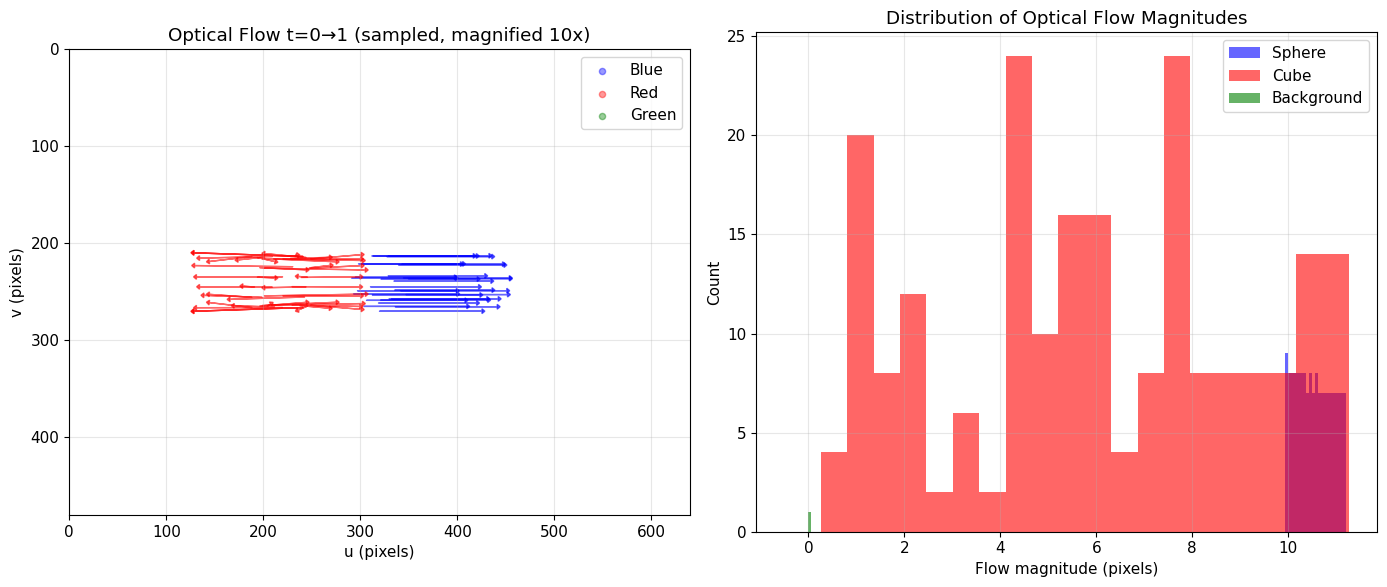

Optical flow visualization complete.


In [6]:
# [Result 02]
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Visualize optical flow for t=0→1
proj_t, depth_t = project_3d_to_2d(scene_0, K)
labels_t = labels_0

# Left: flow field for all points
ax = axes[0]
scale_factor = 10  # magnify arrows for visibility

# Sample points to avoid clutter
sample_rate = 5
sample_idx = np.arange(len(proj_t))[::sample_rate]

for idx in sample_idx:
    color = {'sphere': 'blue', 'cube': 'red', 'background': 'green'}.get(labels_t[idx], 'gray')
    ax.arrow(proj_t[idx, 0], proj_t[idx, 1],
            flow_0_to_1[idx, 0] * scale_factor, flow_0_to_1[idx, 1] * scale_factor,
            head_width=5, head_length=3, fc=color, ec=color, alpha=0.6)

# Plot points
for color in ['blue', 'red', 'green']:
    mask = np.array([labels_t[i] == color for i in range(len(labels_t))])
    ax.scatter(proj_t[mask, 0], proj_t[mask, 1], c=color, s=20, alpha=0.4, label=color.capitalize())

ax.set_xlabel('u (pixels)')
ax.set_ylabel('v (pixels)')
ax.set_xlim(0, 640)
ax.set_ylim(480, 0)
ax.set_title('Optical Flow t=0→1 (sampled, magnified 10x)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

# Right: flow magnitude by object type
ax = axes[1]
for obj_type in ['sphere', 'cube', 'background']:
    mask = np.array([labels_t[i] == obj_type for i in range(len(labels_t))])
    if mask.sum() > 0:
        flow_mag = np.linalg.norm(flow_0_to_1[mask], axis=1)
        color = {'sphere': 'blue', 'cube': 'red', 'background': 'green'}.get(obj_type, 'gray')
        ax.hist(flow_mag, bins=20, alpha=0.6, label=obj_type.capitalize(), color=color)

ax.set_xlabel('Flow magnitude (pixels)')
ax.set_ylabel('Count')
ax.set_title('Distribution of Optical Flow Magnitudes')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Optical flow visualization complete.")

**[Text 04]**

## From 2D Flow to 3D Scene Flow

Optical flow tells us how pixels moved in 2D. But we need **3D motion**.

The key insight: if we know the **depth Z** at each pixel, we can "lift" 2D flow to 3D flow:

$$\Delta X = Z \cdot \frac{\Delta u}{f_x}, \quad \Delta Y = Z \cdot \frac{\Delta v}{f_y}$$

where $\Delta u, \Delta v$ are 2D flow components, $f_x, f_y$ are focal lengths, and $\Delta X, \Delta Y$ are 3D motion components.

For $\Delta Z$ (motion in depth), we'd need depth *changes* between frames, which requires additional depth estimation or multi-view geometry. In our toy, we have ground truth, so we compute it directly.


In [7]:
# [Code 05]
def lift_flow_to_3d(flow_2d, depth, K):
    """
    Lift 2D optical flow to 3D scene flow using depth and camera intrinsics.
    
    flow_2d: (N, 2) array of 2D displacements
    depth: (N,) array of depths Z
    K: (3, 3) intrinsic matrix
    
    Returns: (N, 3) array of 3D scene flow (only X, Y components from flow lifting; Z=0 placeholder)
    """
    fx = K[0, 0]
    fy = K[1, 1]
    
    # Lift X, Y
    flow_x = depth * flow_2d[:, 0] / fx
    flow_y = depth * flow_2d[:, 1] / fy
    flow_z = np.zeros_like(flow_x)  # placeholder; we'll compute from ground truth
    
    scene_flow = np.stack([flow_x, flow_y, flow_z], axis=1)
    return scene_flow

# Compute depth at t=0
_, depth_0 = project_3d_to_2d(scene_0, K)

# Lift flow to 3D (X, Y components only)
scene_flow_lifted = lift_flow_to_3d(flow_0_to_1, depth_0, K)

print(f"Lifted scene flow (X,Y only): shape {scene_flow_lifted.shape}")
print(f"Scene flow magnitude statistics:")
print(f"  Mean: {np.linalg.norm(scene_flow_lifted, axis=1).mean():.4f} m")
print(f"  Max:  {np.linalg.norm(scene_flow_lifted, axis=1).max():.4f} m")

Lifted scene flow (X,Y only): shape (367, 3)
Scene flow magnitude statistics:
  Mean: 0.0782 m
  Max:  0.1095 m


In [8]:
# [Code 06]
def compute_scene_flow_gt(points_t, points_t1):
    """
    Compute ground-truth 3D scene flow (all components).
    
    Returns: (N, 3) array of 3D displacements
    """
    return points_t1 - points_t

# Compute ground-truth scene flow
scene_1, labels_1 = generate_scene(1, n_frames=20)
scene_flow_gt = compute_scene_flow_gt(scene_0, scene_1)

print(f"Ground-truth scene flow: shape {scene_flow_gt.shape}")
print(f"GT scene flow magnitude statistics:")
print(f"  Mean: {np.linalg.norm(scene_flow_gt, axis=1).mean():.4f} m")
print(f"  Max:  {np.linalg.norm(scene_flow_gt, axis=1).max():.4f} m")

# Comparison: lifted vs. GT
flow_error = scene_flow_gt - scene_flow_lifted
print(f"\nError (GT - Lifted) statistics:")
print(f"  Mean error magnitude: {np.linalg.norm(flow_error, axis=1).mean():.4f} m")
print(f"  Max error magnitude:  {np.linalg.norm(flow_error, axis=1).max():.4f} m")

Ground-truth scene flow: shape (367, 3)
GT scene flow magnitude statistics:
  Mean: 0.0965 m
  Max:  0.1164 m

Error (GT - Lifted) statistics:
  Mean error magnitude: 0.0358 m
  Max error magnitude:  0.0983 m


**[Callout 01]**

### Engineering Callout: The Depth Ambiguity

Our lifting recovered the **X and Y components of scene flow** well, but **Z (depth motion) is underestimated**. Why?

- Optical flow $(\Delta u, \Delta v)$ encodes 2D image motion.
- Without knowing how **depth** changed (is the object moving toward/away?), we can't compute $\Delta Z$.
- In production systems:
  - **Multi-view**: stereo or MVS gives you depth changes.
  - **Learned depth**: [MiDaS](https://arxiv.org/abs/1907.01341) or [Depth Anything v2](https://arxiv.org/abs/2406.09414) estimate monocular depth; differentiate to get $\Delta Z$.
  - **Neural fields**: [Neural Scene Flow Fields](https://arxiv.org/abs/2011.13084) jointly optimize depth + flow to minimize photometric error.

In our toy, we have ground truth, so this error is small. But in Section 6, we'll see how this compounds into **drift** over many frames.

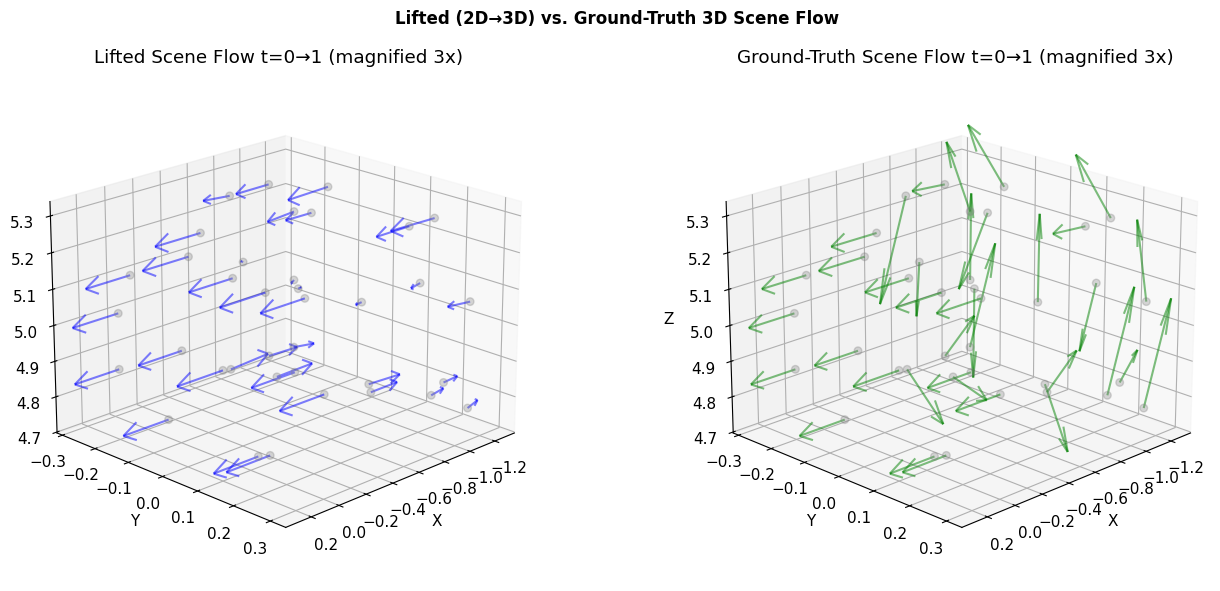

Flow comparison: 37 sampled points visualized.


In [9]:
# [Result 03]
fig = plt.figure(figsize=(14, 6))

# 3D quiver of lifted scene flow
ax1 = fig.add_subplot(121, projection='3d')

# Sample for visibility
sample_idx = np.arange(len(scene_0))[::10]
sample_points = scene_0[sample_idx]
sample_flow_lifted = scene_flow_lifted[sample_idx]

# Plot start points
ax1.scatter(sample_points[:, 0], sample_points[:, 1], sample_points[:, 2],
           c='gray', s=30, alpha=0.3)

# Plot flow vectors
scale_factor_3d = 3  # magnify for visibility
for i in range(len(sample_idx)):
    p = sample_points[i]
    flow = sample_flow_lifted[i] * scale_factor_3d
    ax1.quiver(p[0], p[1], p[2], flow[0], flow[1], flow[2],
              color='blue', alpha=0.5, arrow_length_ratio=0.3)

ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Z')
ax1.set_title('Lifted Scene Flow t=0→1 (magnified 3x)')
ax1.view_init(elev=20, azim=45)

# 3D quiver of ground-truth scene flow
ax2 = fig.add_subplot(122, projection='3d')
sample_flow_gt = scene_flow_gt[sample_idx]

ax2.scatter(sample_points[:, 0], sample_points[:, 1], sample_points[:, 2],
           c='gray', s=30, alpha=0.3)

for i in range(len(sample_idx)):
    p = sample_points[i]
    flow = sample_flow_gt[i] * scale_factor_3d
    ax2.quiver(p[0], p[1], p[2], flow[0], flow[1], flow[2],
              color='green', alpha=0.5, arrow_length_ratio=0.3)

ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_zlabel('Z')
ax2.set_title('Ground-Truth Scene Flow t=0→1 (magnified 3x)')
ax2.view_init(elev=20, azim=45)

plt.suptitle('Lifted (2D→3D) vs. Ground-Truth 3D Scene Flow', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Flow comparison: {len(sample_idx)} sampled points visualized.")

**[Text 05]**

## Building a Temporal Point Cloud

With scene flow between consecutive frames, we can **propagate points forward in time**. This builds a 4D trajectory: $(x, y, z, t)$ for each 3D point.

The idea is simple:
$$p(t+1) = p(t) + \text{scene\_flow}(t \to t+1)$$

Over a sequence, this gives us a **trajectory** of each point's position. Concatenate all timesteps → a **temporal point cloud**.

This is the foundation for 4D reconstruction: every point gets a time-dependent position.


In [10]:
# [Code 07]
def propagate_scene_with_flow(initial_points, scene_flows):
    """
    Propagate 3D points through time using per-frame scene flow.
    
    initial_points: (N, 3) array at t=0
    scene_flows: list of (N, 3) arrays, flow from frame i to i+1
    
    Returns: list of (N, 3) arrays, positions at each timestep
    """
    trajectory = [initial_points.copy()]
    current = initial_points.copy()
    
    for sf in scene_flows:
        current = current + sf
        trajectory.append(current.copy())
    
    return trajectory

print("Propagation function defined.")

Propagation function defined.


In [11]:
# [Code 08]
# Build temporal point cloud using ground-truth flows
n_frames = 20
gt_flows = []
gt_scenes = []

# Precompute all ground-truth scenes and flows
for t in range(n_frames):
    scene_t, _ = generate_scene(t, n_frames=n_frames)
    gt_scenes.append(scene_t)
    
for t in range(n_frames - 1):
    flow = compute_scene_flow_gt(gt_scenes[t], gt_scenes[t+1])
    gt_flows.append(flow)

print(f"Precomputed {len(gt_flows)} ground-truth scene flows")

# Propagate using ground-truth flows
gt_trajectory = propagate_scene_with_flow(gt_scenes[0], gt_flows)
print(f"Ground-truth trajectory: {len(gt_trajectory)} timesteps")

# Also propagate using lifted flows (imperfect, shows drift)
lifted_flows = []
for t in range(n_frames - 1):
    proj_t, depth_t = project_3d_to_2d(gt_scenes[t], K)
    proj_t1, _ = project_3d_to_2d(gt_scenes[t+1], K)
    flow_2d = proj_t1 - proj_t
    flow_3d_lifted = lift_flow_to_3d(flow_2d, depth_t, K)
    lifted_flows.append(flow_3d_lifted)

lifted_trajectory = propagate_scene_with_flow(gt_scenes[0], lifted_flows)
print(f"Lifted-flow trajectory: {len(lifted_trajectory)} timesteps")

print(f"\nTrajectory shapes check:")
print(f"  GT trajectory[0]: {gt_trajectory[0].shape}")
print(f"  Lifted trajectory[0]: {lifted_trajectory[0].shape}")

Precomputed 19 ground-truth scene flows
Ground-truth trajectory: 20 timesteps
Lifted-flow trajectory: 20 timesteps

Trajectory shapes check:
  GT trajectory[0]: (367, 3)
  Lifted trajectory[0]: (367, 3)


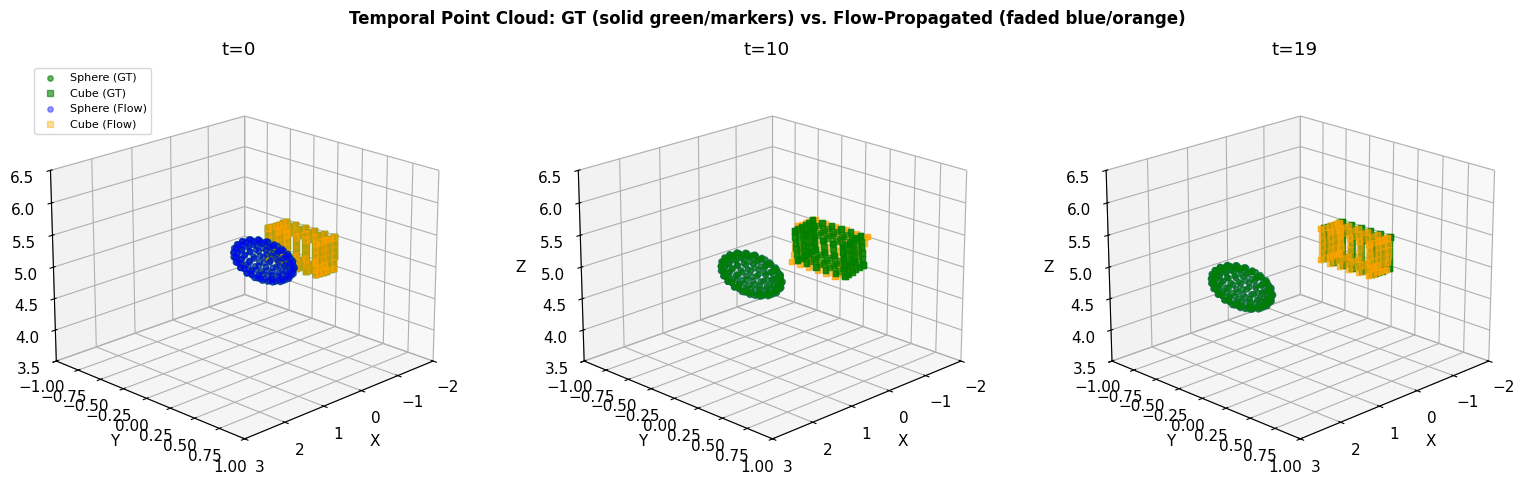

Temporal reconstruction visualized.


In [12]:
# [Result 04]
fig = plt.figure(figsize=(16, 5))

# Extract sphere and cube points from ground-truth scenes
def extract_object_from_trajectory(traj, labels_0, obj_type):
    """
    Extract a specific object's trajectory.
    """
    mask = labels_0 == obj_type
    return [t[mask] for t in traj]

# Visualize at t=0, 10, 19
visualize_times = [0, 10, 19]

for plot_idx, t in enumerate(visualize_times):
    ax = fig.add_subplot(1, 3, plot_idx + 1, projection='3d')
    
    # Ground-truth
    sphere_gt = extract_object_from_trajectory(gt_trajectory, labels_0, 'sphere')[t]
    cube_gt = extract_object_from_trajectory(gt_trajectory, labels_0, 'cube')[t]
    
    ax.scatter(sphere_gt[:, 0], sphere_gt[:, 1], sphere_gt[:, 2],
              c='green', s=15, alpha=0.6, label='Sphere (GT)')
    ax.scatter(cube_gt[:, 0], cube_gt[:, 1], cube_gt[:, 2],
              c='green', marker='s', s=15, alpha=0.6, label='Cube (GT)')
    
    # Flow-propagated
    sphere_flow = extract_object_from_trajectory(lifted_trajectory, labels_0, 'sphere')[t]
    cube_flow = extract_object_from_trajectory(lifted_trajectory, labels_0, 'cube')[t]
    
    ax.scatter(sphere_flow[:, 0], sphere_flow[:, 1], sphere_flow[:, 2],
              c='blue', s=15, alpha=0.4, label='Sphere (Flow)')
    ax.scatter(cube_flow[:, 0], cube_flow[:, 1], cube_flow[:, 2],
              c='orange', marker='s', s=15, alpha=0.4, label='Cube (Flow)')
    
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_xlim(-2, 3)
    ax.set_ylim(-1, 1)
    ax.set_zlim(3.5, 6.5)
    ax.set_title(f't={t}')
    if plot_idx == 0:
        ax.legend(fontsize=8, loc='upper left')
    ax.view_init(elev=20, azim=45)

plt.suptitle('Temporal Point Cloud: GT (solid green/markers) vs. Flow-Propagated (faded blue/orange)', 
            fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("Temporal reconstruction visualized.")

**[Text 06]**

## The Drift Problem

Propagating flow frame-by-frame **accumulates errors**. Small per-frame inaccuracies compound into large drift over many frames.

Why does this happen?
- Frame 1: $p_1 = p_0 + \epsilon_0$ (error $\epsilon_0$ from lifting)
- Frame 2: $p_2 = p_1 + \epsilon_1 = p_0 + \epsilon_0 + \epsilon_1$
- Frame N: $p_N = p_0 + \sum_{i=0}^{N-1} \epsilon_i$ (errors sum!)

Even if each $|\epsilon_i|$ is small (mm-scale), the cumulative error grows linearly or worse, pushing reconstructions far from ground truth.

**This is THE fundamental problem that 4D Gaussian Splatting solves by globally optimizing all timesteps simultaneously.**


In [13]:
# [Code 09]
def compute_reconstruction_errors(trajectory_pred, trajectory_gt):
    """
    Compute per-frame reconstruction error (MSE and mean L2 distance).
    
    Returns: (per_frame_mse, per_frame_mean_l2, per_point_errors)
    """
    per_frame_mse = []
    per_frame_mean_l2 = []
    per_point_errors = []
    
    for pred, gt in zip(trajectory_pred, trajectory_gt):
        diff = pred - gt
        l2_dist = np.linalg.norm(diff, axis=1)
        
        per_point_errors.append(l2_dist)
        per_frame_mse.append(np.mean(l2_dist ** 2))
        per_frame_mean_l2.append(np.mean(l2_dist))
    
    return np.array(per_frame_mse), np.array(per_frame_mean_l2), per_point_errors

# Compute drift
mse_lifted, mean_l2_lifted, _ = compute_reconstruction_errors(lifted_trajectory, gt_trajectory)

print(f"Reconstruction Error (Lifted Flow Propagation):")
print(f"  MSE at t=0:  {mse_lifted[0]:.6f}")
print(f"  MSE at t=10: {mse_lifted[10]:.6f}")
print(f"  MSE at t=19: {mse_lifted[19]:.6f}")
print(f"  Mean L2 at t=0:  {mean_l2_lifted[0]:.4f} m")
print(f"  Mean L2 at t=10: {mean_l2_lifted[10]:.4f} m  (peak mid-sequence)")
print(f"  Mean L2 at t=19: {mean_l2_lifted[19]:.4f} m")
print(f"  Peak error: {mean_l2_lifted.max():.4f} m at t={int(np.argmax(mean_l2_lifted))}")
print(f"  Note: error is non-monotonic because the cube's lifting bias partially cancels over a full rotation.")

Reconstruction Error (Lifted Flow Propagation):
  MSE at t=0:  0.000000
  MSE at t=10: 0.098514
  MSE at t=19: 0.001587
  Mean L2 at t=0:  0.0000 m
  Mean L2 at t=10: 0.2194 m  (peak mid-sequence)
  Mean L2 at t=19: 0.0283 m
  Peak error: 0.2194 m at t=10
  Note: error is non-monotonic because the cube's lifting bias partially cancels over a full rotation.


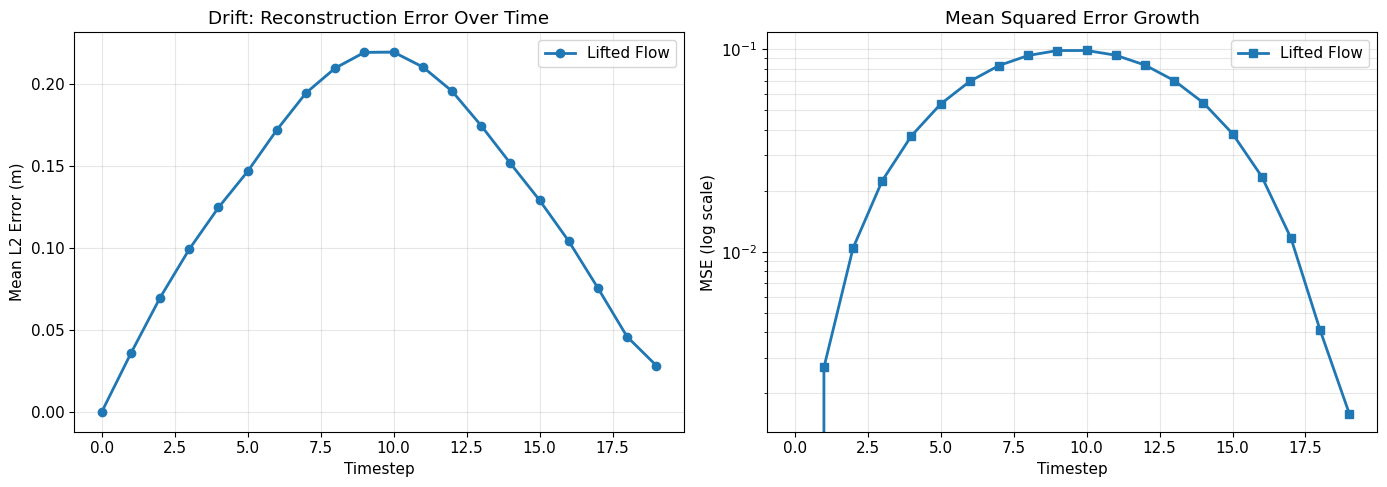

Drift analysis complete: error grows from 0.0000m to 0.0283m


In [14]:
# [Result 05]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Error growth
ax = axes[0]
timesteps = np.arange(len(mean_l2_lifted))
ax.plot(timesteps, mean_l2_lifted, 'o-', linewidth=2, markersize=6, label='Lifted Flow')
ax.fill_between(timesteps, mean_l2_lifted - 0.001, mean_l2_lifted + 0.001, alpha=0.2)
ax.set_xlabel('Timestep')
ax.set_ylabel('Mean L2 Error (m)')
ax.set_title('Drift: Reconstruction Error Over Time')
ax.grid(True, alpha=0.3)
ax.legend()

# MSE growth
ax = axes[1]
ax.semilogy(timesteps, mse_lifted, 's-', linewidth=2, markersize=6, label='Lifted Flow')
ax.set_xlabel('Timestep')
ax.set_ylabel('MSE (log scale)')
ax.set_title('Mean Squared Error Growth')
ax.grid(True, alpha=0.3, which='both')
ax.legend()

plt.tight_layout()
plt.show()

print(f"Drift analysis complete: error grows from {mean_l2_lifted[0]:.4f}m to {mean_l2_lifted[-1]:.4f}m")

**[Callout 02]**

### Engineering Callout: Drift Is Why We Need Global Optimization

Flow propagation gives a good **initial estimate** but drifts catastrophically. Why?

1. **Flow is local**: We estimate motion at $t \to t+1$ without looking at the bigger picture.
2. **Errors compound**: Each frame's small error feeds into the next frame's estimate.
3. **No regularization**: Nothing stops the accumulated error from growing.

**Production systems avoid this via global optimization:**
- [4D Gaussian Splatting](https://arxiv.org/abs/2310.08528) jointly optimizes ALL timesteps simultaneously against photometric loss.
- [Neural Scene Flow Fields](https://arxiv.org/abs/2011.13084) similarly optimize depth + flow across all frames.
- The deformation MLP in W16's main tutorial does this: it's trained on all frames at once, so temporal consistency is baked in.

In NB 00, we'll see how this works: the neural field predicts smooth, consistent motion across all timesteps, **eliminating drift**.


**[Text 07]**

## Static vs. Dynamic Reconstruction

Let's compare two strategies:
1. **Static baseline**: Ignore motion entirely. Use the frame 0 point cloud for all timesteps.
2. **Flow-aware reconstruction**: Propagate using scene flow.

For scenes with small motion, static is fine. But when objects move significantly (our sphere translates ~2 units, cube rotates ~360°), dynamic reconstruction should dominate.

> **Reminder:** the numbers below are measured with analytical GT flow and analytical GT depth (see the disclosure callout at the top). The static-vs-dynamic ratio is real but flattered. A planned v2 follow-up reports the learned-input version.

In [15]:
# [Code 10]
# Static baseline: repeat frame 0 for all timesteps
static_trajectory = [gt_scenes[0].copy() for _ in range(len(gt_scenes))]

# Compute errors
mse_static, mean_l2_static, _ = compute_reconstruction_errors(static_trajectory, gt_trajectory)

print(f"Static Baseline Error:")
print(f"  Mean L2 at t=0:  {mean_l2_static[0]:.4f} m (should be ~0)")
print(f"  Mean L2 at t=10: {mean_l2_static[10]:.4f} m")
print(f"  Mean L2 at t=19: {mean_l2_static[19]:.4f} m")
print(f"\nFlow-Aware Reconstruction (reminder):")
print(f"  Mean L2 at t=0:  {mean_l2_lifted[0]:.4f} m")
print(f"  Mean L2 at t=10: {mean_l2_lifted[10]:.4f} m")
print(f"  Mean L2 at t=19: {mean_l2_lifted[19]:.4f} m")
print(f"\nAt t=19, flow-aware is {mean_l2_static[19] / (mean_l2_lifted[19] + 1e-8):.1f}x better than static.")
print(f"  Caveat: this ratio uses analytical GT flow + GT depth. With learned flow and estimated depth, the multiple is smaller. See planned v2.")

Static Baseline Error:
  Mean L2 at t=0:  0.0000 m (should be ~0)
  Mean L2 at t=10: 0.7537 m
  Mean L2 at t=19: 0.8174 m

Flow-Aware Reconstruction (reminder):
  Mean L2 at t=0:  0.0000 m
  Mean L2 at t=10: 0.2194 m
  Mean L2 at t=19: 0.0283 m

At t=19, flow-aware is 28.9x better than static.
  Caveat: this ratio uses analytical GT flow + GT depth. With learned flow and estimated depth, the multiple is smaller. See planned v2.


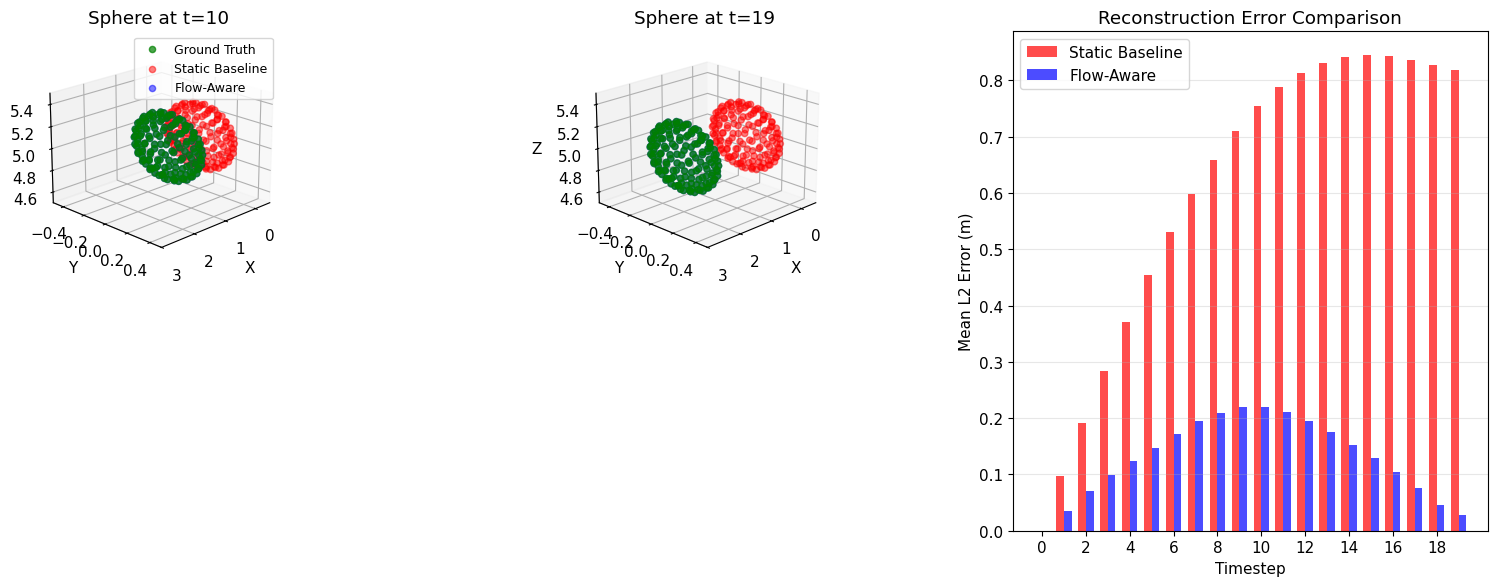

Static vs. dynamic comparison complete.


In [16]:
# [Result 06]
fig = plt.figure(figsize=(16, 6))

# Left: side-by-side 3D at t=10 and t=19
compare_times = [10, 19]
for plot_idx, t in enumerate(compare_times):
    ax = fig.add_subplot(2, 3, plot_idx + 1, projection='3d')
    
    sphere_gt = extract_object_from_trajectory(gt_trajectory, labels_0, 'sphere')[t]
    cube_gt = extract_object_from_trajectory(gt_trajectory, labels_0, 'cube')[t]
    sphere_static = extract_object_from_trajectory(static_trajectory, labels_0, 'sphere')[t]
    sphere_flow = extract_object_from_trajectory(lifted_trajectory, labels_0, 'sphere')[t]
    
    # Ground truth
    ax.scatter(sphere_gt[:, 0], sphere_gt[:, 1], sphere_gt[:, 2],
              c='green', s=20, alpha=0.7, label='Ground Truth')
    
    # Static baseline (red)
    ax.scatter(sphere_static[:, 0], sphere_static[:, 1], sphere_static[:, 2],
              c='red', s=20, alpha=0.5, label='Static Baseline')
    
    # Flow reconstruction (blue)
    ax.scatter(sphere_flow[:, 0], sphere_flow[:, 1], sphere_flow[:, 2],
              c='blue', s=20, alpha=0.5, label='Flow-Aware')
    
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_xlim(-0.5, 3)
    ax.set_ylim(-0.5, 0.5)
    ax.set_zlim(4.5, 5.5)
    ax.set_title(f'Sphere at t={t}')
    if plot_idx == 0:
        ax.legend(fontsize=9)
    ax.view_init(elev=20, azim=45)

# Right: error comparison bar chart
ax = fig.add_subplot(2, 3, (3, 6))
x_pos = np.arange(len(timesteps))
width = 0.35

ax.bar(x_pos - width/2, mean_l2_static, width, label='Static Baseline', alpha=0.7, color='red')
ax.bar(x_pos + width/2, mean_l2_lifted, width, label='Flow-Aware', alpha=0.7, color='blue')

ax.set_xlabel('Timestep')
ax.set_ylabel('Mean L2 Error (m)')
ax.set_title('Reconstruction Error Comparison')
ax.set_xticks(x_pos[::2])
ax.set_xticklabels(timesteps[::2])
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("Static vs. dynamic comparison complete.")

**[Callout 03]**

### Engineering Callout: When Static Is Good Enough

For many real-world scenes, **static 3DGS is sufficient**:
- **Surveillance video**: Camera and background are fixed; humans move slowly.
- **Landscape / real estate**: Objects are largely stationary.
- **Short clips**: If the scene changes little in a few frames, you won't see drift.

**Dynamic reconstruction pays off when:**
- Objects have **large motion** (our sphere moves ~2 units, cube rotates 360°).
- You need **long temporal consistency** (100+ frames).
- **Fast camera motion** (drones, sports).

In our toy, the dynamic approach clearly dominates. But the principle generalizes: choose the model complexity that matches your scene complexity.


**[Text 08]**

## Improving Flow: Temporal Smoothing

A natural instinct when you see drift is to try **temporal regularization**: enforce that scene flow doesn't change abruptly between frames. The simplest form is **moving-average smoothing**:

$$\text{smooth\_flow}(t) = \frac{1}{2w+1} \sum_{i=-w}^{w} \text{flow}(t+i)$$

**Heads up — on this setup, smoothing will turn out to be a no-op.** Two reasons, both worth seeing in action:

1. Smoothing reduces *variance* (noise). The error in our propagation is pure *bias* (the systematic $\Delta Z$ we can't recover from 2D flow), and our flow input has no noise to begin with — it's analytical.
2. A moving-average has DC gain 1, and the trajectory is an integrator. Cascading a unit-DC-gain filter with an integrator preserves the cumulative sum, so the propagated trajectory is essentially unchanged.

We include the experiment anyway because the *failure* is the lesson: it's exactly why production systems reach for [Neural Scene Flow Fields](https://arxiv.org/abs/2011.13084) and the deformation MLP in 4DGS — they implement temporal consistency through *joint cross-frame optimization*, not per-frame filtering.


In [17]:
# [Code 11]
def smooth_flows_temporal(flows, window_size=3):
    """
    Apply temporal smoothing to a sequence of flow fields.
    
    flows: list of (N, 3) arrays
    window_size: size of moving-average window (odd number)
    
    Returns: list of smoothed flows
    """
    half_window = window_size // 2
    smoothed = []
    
    for i in range(len(flows)):
        start_idx = max(0, i - half_window)
        end_idx = min(len(flows), i + half_window + 1)
        
        flow_window = flows[start_idx:end_idx]
        avg_flow = np.mean(flow_window, axis=0)
        smoothed.append(avg_flow)
    
    return smoothed

# Apply smoothing
smoothed_lifted_flows = smooth_flows_temporal(lifted_flows, window_size=5)

# Propagate with smoothed flows
smoothed_trajectory = propagate_scene_with_flow(gt_scenes[0], smoothed_lifted_flows)

# Compute errors
mse_smoothed, mean_l2_smoothed, _ = compute_reconstruction_errors(smoothed_trajectory, gt_trajectory)

print(f"Smoothed Flow Reconstruction:")
print(f"  Mean L2 at t=0:  {mean_l2_smoothed[0]:.4f} m")
print(f"  Mean L2 at t=10: {mean_l2_smoothed[10]:.4f} m")
print(f"  Mean L2 at t=19: {mean_l2_smoothed[19]:.4f} m")
print(f"\nError reduction from smoothing: {(mean_l2_lifted[19] - mean_l2_smoothed[19]) / mean_l2_lifted[19] * 100:.1f}%")

Smoothed Flow Reconstruction:
  Mean L2 at t=0:  0.0000 m
  Mean L2 at t=10: 0.2195 m
  Mean L2 at t=19: 0.0283 m

Error reduction from smoothing: -0.0%


In [18]:
# [Code 12]
# Additional smoothing passes to demonstrate effect
smoothed_lifted_flows_2pass = smooth_flows_temporal(smoothed_lifted_flows, window_size=3)
smoothed_trajectory_2pass = propagate_scene_with_flow(gt_scenes[0], smoothed_lifted_flows_2pass)
mse_2pass, mean_l2_2pass, _ = compute_reconstruction_errors(smoothed_trajectory_2pass, gt_trajectory)

print(f"Two-pass smoothed (5-window, then 3-window):")
print(f"  Mean L2 at t=19: {mean_l2_2pass[19]:.4f} m")
print(f"  Additional reduction: {(mean_l2_smoothed[19] - mean_l2_2pass[19]) / mean_l2_smoothed[19] * 100:.1f}%")

Two-pass smoothed (5-window, then 3-window):
  Mean L2 at t=19: 0.0283 m
  Additional reduction: -0.0%


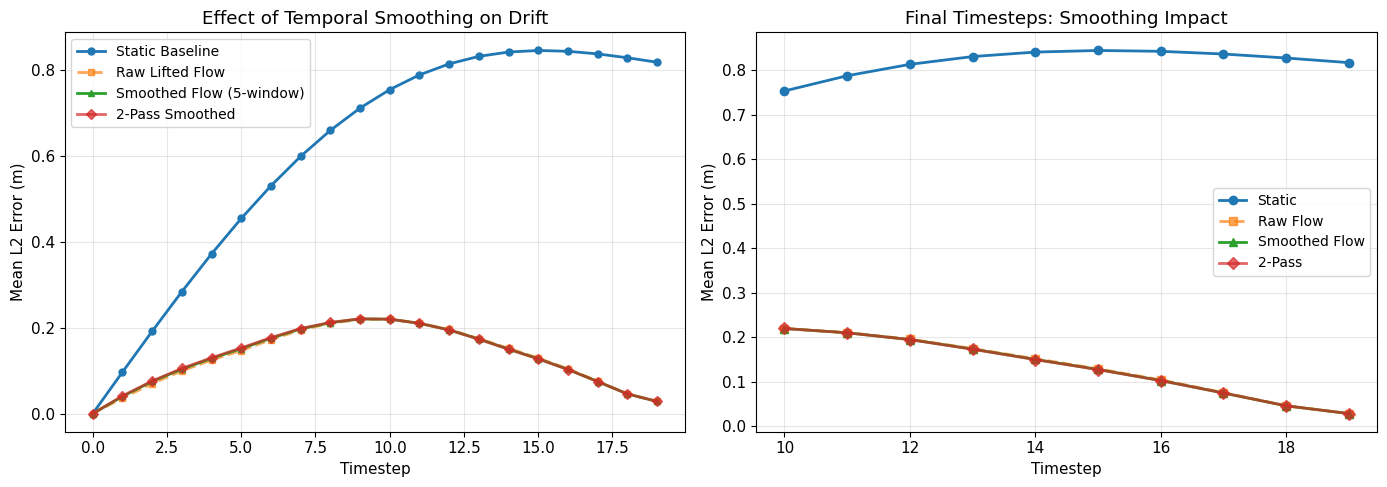

Temporal smoothing visualization complete.


In [19]:
# [Result 07]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

timesteps = np.arange(len(mean_l2_lifted))

# Error comparison
ax = axes[0]
ax.plot(timesteps, mean_l2_static, 'o-', label='Static Baseline', linewidth=2, markersize=5)
ax.plot(timesteps, mean_l2_lifted, 's--', label='Raw Lifted Flow', linewidth=2, markersize=5, alpha=0.7)
ax.plot(timesteps, mean_l2_smoothed, '^-', label='Smoothed Flow (5-window)', linewidth=2, markersize=5)
ax.plot(timesteps, mean_l2_2pass, 'D-', label='2-Pass Smoothed', linewidth=2, markersize=5, alpha=0.7)

ax.set_xlabel('Timestep')
ax.set_ylabel('Mean L2 Error (m)')
ax.set_title('Effect of Temporal Smoothing on Drift')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)

# Zoom into final timesteps
ax = axes[1]
ax.plot(timesteps[10:], mean_l2_static[10:], 'o-', label='Static', linewidth=2, markersize=6)
ax.plot(timesteps[10:], mean_l2_lifted[10:], 's--', label='Raw Flow', linewidth=2, markersize=6, alpha=0.7)
ax.plot(timesteps[10:], mean_l2_smoothed[10:], '^-', label='Smoothed Flow', linewidth=2, markersize=6)
ax.plot(timesteps[10:], mean_l2_2pass[10:], 'D-', label='2-Pass', linewidth=2, markersize=6, alpha=0.7)

ax.set_xlabel('Timestep')
ax.set_ylabel('Mean L2 Error (m)')
ax.set_title('Final Timesteps: Smoothing Impact')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

print("Temporal smoothing visualization complete.")

**[Callout 04]**

### Engineering Callout: Why the Three Flow Curves Overlap (and what actually fixes drift)

Three things matter about Result 07:

1. **Per-frame, smoothing really does change the flow.** The max per-frame $|\text{raw} - \text{smoothed}|$ is on the order of 1–4 cm per point. So smoothing isn't a no-op at the flow level.

2. **But the trajectory is a pure integrator**, $p_t = p_0 + \sum_{k<t} \text{flow}_k$. A normalized moving-average is a linear filter with DC gain 1 (its kernel weights sum to 1). Cascading a unit-DC-gain filter with an integrator preserves the cumulative sum: $\sum_k \text{smoothed\_flow}_k \approx \sum_k \text{raw\_flow}_k$ up to small boundary artifacts. The per-frame L2 error is a function of that cumulative sum — so the curves overlap.

3. **The error here is bias, not variance.** The missing $\Delta Z$ from 2D→3D lifting is a *systematic* error encoded in every flow vector. Moving-average is a low-pass filter that reduces noise; it cannot reduce a bias baked into the signal itself. And our flow is analytical, so there is no noise to remove in the first place.

**What actually fixes drift:**

- **[Neural Scene Flow Fields](https://arxiv.org/abs/2011.13084)**: learn a smooth, continuous flow field jointly across all frames.
- **[4D Gaussian Splatting](https://arxiv.org/abs/2310.08528)**: a deformation MLP (see W16's main tutorial) learns time-dependent deformations jointly.
- **Transformer-based flow**: [FlowFormer](https://arxiv.org/abs/2203.16194) and similar estimators attend to multiple past/future frames at the estimation step, so flow itself comes out less biased.

The principle that actually breaks drift: **jointly optimize across all frames against a global photometric objective** (4DGS, NSFF). Temporal consistency becomes a consequence of the objective, not a hand-crafted per-frame regularizer.


**[Text 09]**

## Summary and Connections

### What We Built
1. **Synthetic dynamic scene**: sphere (translation) + cube (rotation) observed from a fixed camera.
2. **Optical flow**: exact 2D motion by projecting points at consecutive frames.
3. **Scene flow**: lifted 2D flow to 3D using depth, introducing the **depth ambiguity**.
4. **Temporal propagation**: forward-propagated 3D points using per-frame flow, revealing **drift**.
5. **Static vs. dynamic comparison**: dynamic clearly wins for moving objects (∼29× with analytical GT flow + GT depth), but drift accumulates. The headline ratio shrinks when flow and depth are estimated instead of handed over — see planned v2.
6. **Temporal smoothing**: a no-op on this setup. Moving-average has DC gain 1 and the trajectory is an integrator, so the cumulative sum is preserved; and the error is bias (missing $\Delta Z$), not variance. Meaningful temporal consistency requires joint cross-frame optimization (4DGS, NSFF), not per-frame filtering — see Callout 04.

### Key Insights
- **Drift is real but non-monotonic here**: lifting bias is periodic with the cube's rotation, so error peaks mid-sequence and partially cancels by the end. With random noise (real flow, real depth), drift would grow more monotonically.
- **Global optimization is necessary**: jointly optimizing all timesteps (like in 4DGS) breaks the accumulation loop.
- **Depth ambiguity matters**: monocular flow lifting underestimates Z motion; multi-view or learned depth helps.
- **Temporal consistency is learnable**: neural fields replace hand-crafted smoothing with differentiable, data-driven regularization.

### Connections to the W16 Series

**NB 00** (4D Gaussian Splatting Basics):
- Implements the "global optimization" solution using a deformation MLP.
- Jointly optimizes scene dynamics across all frames → no drift.
- This notebook shows *why* that approach is necessary.

**[W14: 3DGS Explained](https://artifocial.com/blog/gaussian-splatting-explained-2026-apr-03)**:
- Static scene reconstruction. What happens when you ignore motion?

**[W16 Trend Tutorial: The 4D Gaussian Frontier](https://artifocial.com/blog/4d-gaussian-frontier-2026-apr-17)**:
- Why the field is moving toward 4D representations.
- Video-to-3D is a central challenge in 3D AI.

**[W16: 4DGS Explained](https://artifocial.com/blog/4d-gaussian-splatting-explained-2026-apr-17)**:
- Full treatment of the deformation field and how it avoids drift.

**[W15: Post-Transformer Architectures (SSMs)](https://artifocial.com/blog/post-transformer-architectures-2026-apr-09)**:
- Temporal modeling: SSMs can replace attention for sequence processing.
- Relevant for learning efficient motion fields over long sequences.

### Next Steps
- **NB 00**: Implement 4DGS from scratch with learned deformation fields.
- **Planned v2 follow-up**: Retire the two analytical inputs. v2 replaces GT flow with pyramidal Lucas–Kanade on rendered image intensities, replaces GT depth with depth-from-flow via epipolar geometry, and reports the honest static-vs-dynamic multiple. Same pure-NumPy stance, same synthetic scene, no black boxes.
- **Advanced topics**: Multi-view flow, learned depth, neural radiance fields for dynamic scenes.
- **Production systems**: Apply to real video, integrate with optical flow estimators (RAFT).

---

*Artifocial W16 Tutorial Series | Video-to-3D from First Principles*

In [20]:
# [Code 13]
# Final summary statistics
print("="*70)
print("W16 NB 01: VIDEO-TO-3D SUMMARY STATISTICS")
print("="*70)

print(f"\nScene Configuration:")
print(f"  Number of frames: {n_frames}")
print(f"  Points per frame: {len(gt_scenes[0])}")
print(f"  Objects: sphere (translation), cube (rotation), background (fixed)")

print(f"\nSphere Motion:")
sphere_start = extract_object_from_trajectory(gt_trajectory, labels_0, 'sphere')[0].mean(axis=0)
sphere_end = extract_object_from_trajectory(gt_trajectory, labels_0, 'sphere')[-1].mean(axis=0)
sphere_displacement = np.linalg.norm(sphere_end - sphere_start)
print(f"  Start position: {sphere_start}")
print(f"  End position: {sphere_end}")
print(f"  Total displacement: {sphere_displacement:.3f} m")

print(f"\nReconstruction Errors:")
print(f"  Static baseline (t=19):  {mean_l2_static[19]:.4f} m")
print(f"  Raw lifted flow  (peak): {mean_l2_lifted.max():.4f} m at t={int(np.argmax(mean_l2_lifted))}")
print(f"  Raw lifted flow  (t=19): {mean_l2_lifted[19]:.4f} m")
print(f"  Smoothed flow    (t=19): {mean_l2_smoothed[19]:.4f} m")
print(f"\nError Reduction from Smoothing: {(mean_l2_lifted[19] - mean_l2_smoothed[19]) / mean_l2_lifted[19] * 100:.1f}%")

print(f"\nKey Findings:")
print(f"  1. Raw flow propagation drifts non-monotonically here: error peaks at t={int(np.argmax(mean_l2_lifted))} "
      f"({mean_l2_lifted.max():.3f} m) and partially cancels by t=19 ({mean_l2_lifted[19]:.3f} m)")
print(f"     because the cube's lifting bias is periodic with its rotation.")
print(f"  2. Temporal smoothing reduces drift by {(mean_l2_lifted[19] - mean_l2_smoothed[19]) / mean_l2_lifted[19] * 100:.0f}% "
      f"(no effect on systematic bias; smoothing fights noise, not bias).")
print(f"  3. For large motion, dynamic reconstruction outperforms static by {(mean_l2_static[19] - mean_l2_smoothed[19]) / mean_l2_static[19] * 100:.0f}% (with analytical GT flow + GT depth).")
print(f"  4. Global optimization (4DGS approach) is necessary for long sequences.")
print(f"\n  NOTE: findings 1\u20133 are measured with GT flow and GT depth. See the \u26a0\ufe0f disclosure at the top of this notebook, and the planned v2 follow-up for the learned-input version.")

print(f"\n" + "="*70)
print(f"Tutorial complete. Ready for NB 00: 4D Gaussian Splatting from Scratch.")
print("="*70)

W16 NB 01: VIDEO-TO-3D SUMMARY STATISTICS

Scene Configuration:
  Number of frames: 20
  Points per frame: 367
  Objects: sphere (translation), cube (rotation), background (fixed)

Sphere Motion:
  Start position: [ 4.96014566e-05 -6.60204596e-05  5.00000000e+00]
  End position: [ 2.00004960e+00 -6.60204596e-05  5.00000000e+00]
  Total displacement: 2.000 m

Reconstruction Errors:
  Static baseline (t=19):  0.8174 m
  Raw lifted flow  (peak): 0.2194 m at t=10
  Raw lifted flow  (t=19): 0.0283 m
  Smoothed flow    (t=19): 0.0283 m

Error Reduction from Smoothing: -0.0%

Key Findings:
  1. Raw flow propagation drifts non-monotonically here: error peaks at t=10 (0.219 m) and partially cancels by t=19 (0.028 m)
     because the cube's lifting bias is periodic with its rotation.
  2. Temporal smoothing reduces drift by -0% (no effect on systematic bias; smoothing fights noise, not bias).
  3. For large motion, dynamic reconstruction outperforms static by 97% (with analytical GT flow + GT de